# 🏋️ Exercice Intégrateur — L'Analyste Junior (Préparation Examen)

Vous venez d'être embauché(e) comme Junior Data Analyst chez TheLook, une boutique de mode en ligne.
Votre manager vous confie un premier fichier de ventes et attend un rapport d'exploration complet.

> 💡 **Note:** Cet exercice est la version guidée et concentrée de ce qui vous attend cet après-midi pour votre projet final (qui servira d'examen). 
> Profitez de cette session (1h15) pour valider vos acquis : chargement, exploration, **nettoyage**, filtrage, transformation et statistiques descriptives.

In [1]:
import numpy as np
import pandas as pd

## Étape 1 : Charger & Explorer
Chargez le fichier des ventes et produisez un rapport d'exploration complet.

In [2]:
# Chargez le dataset (utilisez la version 'dirty' pour vous entraîner au nettoyage)
sales = pd.read_csv('../01_data/exercises/thelook_sales_dirty.csv')

In [ ]:
# Combien de lignes et colonnes ?
sales

<class 'pandas.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              51000 non-null  int64  
 1   order_id        51000 non-null  int64  
 2   user_id         51000 non-null  int64  
 3   product_id      51000 non-null  int64  
 4   sale_price      46961 non-null  float64
 5   status          51000 non-null  str    
 6   created_at      51000 non-null  str    
 7   shipped_at      42962 non-null  str    
 8   delivered_at    36655 non-null  str    
 9   returned_at     3597 non-null   str    
 10  product_name    51000 non-null  str    
 11  category        44280 non-null  str    
 12  brand           51000 non-null  str    
 13  department      51000 non-null  str    
 14  cost            51000 non-null  str    
 15  gender          51000 non-null  str    
 16  age             48498 non-null  float64
 17  country         51000 non-null  str    
 1

In [6]:
# Quels sont les types de chaque colonne ? (une seule commande)
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              51000 non-null  int64  
 1   order_id        51000 non-null  int64  
 2   user_id         51000 non-null  int64  
 3   product_id      51000 non-null  int64  
 4   sale_price      46961 non-null  float64
 5   status          51000 non-null  str    
 6   created_at      51000 non-null  str    
 7   shipped_at      42962 non-null  str    
 8   delivered_at    36655 non-null  str    
 9   returned_at     3597 non-null   str    
 10  product_name    51000 non-null  str    
 11  category        44280 non-null  str    
 12  brand           51000 non-null  str    
 13  department      51000 non-null  str    
 14  cost            51000 non-null  str    
 15  gender          51000 non-null  str    
 16  age             48498 non-null  float64
 17  country         51000 non-null  str    
 1

In [7]:
# Y a-t-il des valeurs manquantes ? (une seule commande)
sales.isna().sum() 

id                    0
order_id              0
user_id               0
product_id            0
sale_price         4039
status                0
created_at            0
shipped_at         8038
delivered_at      14345
returned_at       47403
product_name          0
category           6720
brand                 0
department            0
cost                  0
gender                0
age                2502
country               0
city                  0
traffic_source        0
dtype: int64

## Étape 1.5 : Nettoyer les données
Votre exploration a révélé des problèmes. Avant de faire des statistiques, il faut s'assurer que les données sont propres.

In [11]:
# Traitez les valeurs manquantes (imputez ou supprimez en justifiant votre choix en commentaire)
sales_copy = sales.copy()
sales_copy.dropna(inplace=True)

In [12]:
#verifier les valeurs manquants
sales_copy.isna().sum() 

id                0
order_id          0
user_id           0
product_id        0
sale_price        0
status            0
created_at        0
shipped_at        0
delivered_at      0
returned_at       0
product_name      0
category          0
brand             0
department        0
cost              0
gender            0
age               0
country           0
city              0
traffic_source    0
dtype: int64

In [22]:
# Vérifiez les duplicata
sales_copy.duplicated()

42       False
45       False
49       False
61       False
77       False
         ...  
50839     True
50935     True
50952    False
50957    False
50986     True
Length: 2727, dtype: bool

In [23]:
#Supprimez les doublons exacts s'il y en a
sales_copy.drop_duplicates()

,id,order_id,user_id,product_id,sale_price,status,created_at,shipped_at,delivered_at,returned_at,product_name,category,brand,department,cost,gender,age,country,city,traffic_source
42,43,2000,1309,600,38.87,Returned,2023-07-14 01:05:58,2023-07-16 01:05:58,2023-07-26 01:05:58,2023-08-10 01:05:58,Levi's Premium Jumpsuits & Rompers,Jumpsuits & Rompers,Levi's,Women,$15.67,F,35.0,Belgium,Ghent,Organic
45,46,5091,1046,283,68.80,Returned,2024-08-02 02:58:14,2024-08-04 02:58:14,2024-08-07 02:58:14,2024-09-04 02:58:14,Carhartt Comfort Jumpsuits & Rompers,Jumpsuits & Rompers,Carhartt,Women,$34.14,M,34.0,United States,Phoenix,Organic
49,50,12292,3775,212,362.21,Returned,2024-02-05 18:27:37,2024-02-08 18:27:37,2024-02-15 18:27:37,2024-03-11 18:27:37,Hurley Slim Fit Outerwear & Coats,Outerwear & Coats,Hurley,Men,$141.69,M,36.0,Mexico,Guadalajara,Search
61,62,47,2176,350,49.03,Returned,2023-02-17 15:00:17,2023-02-18 15:00:17,2023-02-24 15:00:17,2023-03-07 15:00:17,Calvin Klein Essential Tops & Tees,Tops & Tees,Calvin Klein,Men,$24.74,M,34.0,Germany,Frankfurt,Email
77,78,14767,385,1311,41.29,Returned,2024-05-30 23:31:24,2024-06-02 23:31:24,2024-06-05 23:31:24,2024-06-23 23:31:24,Adidas Modern Leggings,Leggings,Adidas,Men,$26.25,M,36.0,Poland,Łódź,Email
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50749,44906,19272,3263,716,59.32,Returned,2024-07-19 21:38:29,2024-07-22 21:38:29,2024-07-27 21:38:29,2024-08-23 21:38:29,Lucky Brand Classic Jeans,Jeans,Lucky Brand,Men,$31.88,M,28.0,Mexico,Mexico City,Search
50776,2997,6500,1998,1867,96.40,Returned,2023-06-26 20:28:57,2023-06-27 20:28:57,2023-06-30 20:28:57,2023-07-11 20:28:57,Levi's Original Skirts,Skirts,Levi's,Men,$36.98,F,25.0,United States,New York,Organic
50797,21746,10990,4274,71,46.97,Returned,2023-08-13 02:37:58,2023-08-14 02:37:58,2023-08-24 02:37:58,2023-08-31 02:37:58,Carhartt Essential Jeans,Jeans,Carhartt,Men,$20.05,M,42.0,United States,Chicago,Facebook
50952,10076,4735,885,56,24.21,Returned,2023-11-14 04:31:31,2023-11-15 04:31:31,2023-11-20 04:31:31,2023-11-29 04:31:31,Levi's Premium Jumpsuits & Rompers,Jumpsuits & Rompers,Levi's,Men,$10.32,F,41.0,spain,Seville,Search


In [ ]:
# Standardisez une colonne texte (ex: mettez les noms de pays en minuscules et sans espaces autour pour vérifier la propreté)
sales_copy['country'] = sales_copy['country'].str.lower().str.strip()

42             belgium
45       united states
49              mexico
61             germany
77              poland
             ...      
50839           france
50935            spain
50952            spain
50957        australia
50986           france
Name: country, Length: 2727, dtype: str

## Étape 2 : Filtrer
Votre manager s'intéresse uniquement au département **Women** et aux ventes de l'année la plus récente.

In [30]:
# Convertissez created_at en datetime
sales_copy['created_at'] = pd.to_datetime(sales_copy['created_at'], errors='coerce')
# Trouvez l'année la plus récente
latest_year = sales_copy['created_at'].dt.year.max()

In [31]:
#verifier les types de chaque colonne après nettoyage
sales_copy.info()

<class 'pandas.DataFrame'>
Index: 2727 entries, 42 to 50986
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id              2727 non-null   int64         
 1   order_id        2727 non-null   int64         
 2   user_id         2727 non-null   int64         
 3   product_id      2727 non-null   int64         
 4   sale_price      2727 non-null   float64       
 5   status          2727 non-null   str           
 6   created_at      2727 non-null   datetime64[us]
 7   shipped_at      2727 non-null   str           
 8   delivered_at    2727 non-null   str           
 9   returned_at     2727 non-null   str           
 10  product_name    2727 non-null   str           
 11  category        2727 non-null   str           
 12  brand           2727 non-null   str           
 13  department      2727 non-null   str           
 14  cost            2727 non-null   str           
 15  gender          27

In [36]:
# Appliquez le double filtre (women department & annee la plus récente)
sales_filtered = sales_copy[(sales_copy['department'].str.lower() == 'women') & (sales_copy['created_at'].dt.year == latest_year)]


In [37]:
#verifier les nouvelles valeurs
sales_filtered

,id,order_id,user_id,product_id,sale_price,status,created_at,shipped_at,delivered_at,returned_at,product_name,category,brand,department,cost,gender,age,country,city,traffic_source
45,46,5091,1046,283,68.80,Returned,2024-08-02 02:58:14,2024-08-04 02:58:14,2024-08-07 02:58:14,2024-09-04 02:58:14,Carhartt Comfort Jumpsuits & Rompers,Jumpsuits & Rompers,Carhartt,Women,$34.14,M,34.0,united states,Phoenix,Organic
95,96,387,942,1515,243.55,Returned,2024-06-02 09:57:41,2024-06-05 09:57:41,2024-06-08 09:57:41,2024-06-14 09:57:41,Carhartt Pro Suits & Sport Coats,Suits & Sport Coats,Carhartt,Women,$166.80,F,45.0,united states,Houston,Facebook
190,191,16896,1557,1193,39.72,Returned,2024-02-20 09:42:18,2024-02-23 09:42:18,2024-02-28 09:42:18,2024-03-17 09:42:18,Carhartt Comfort Fashion Hoodies & Sweatshirts,Fashion Hoodies & Sweatshirts,Carhartt,Women,$21.23,M,23.0,spain,Barcelona,Email
212,213,18111,790,1515,207.22,Returned,2024-11-04 02:03:59,2024-11-07 02:03:59,2024-11-12 02:03:59,2024-11-27 02:03:59,Carhartt Pro Suits & Sport Coats,Suits & Sport Coats,Carhartt,Women,$166.80,F,48.0,u.s.a.,Houston,Search
241,242,15966,772,646,93.60,Returned,2024-05-19 19:51:07,2024-05-20 19:51:07,2024-05-26 19:51:07,2024-06-13 19:51:07,Allegra K Vintage Skirts,Skirts,Allegra K,Women,$36.36,M,34.0,australia,Brisbane,Facebook
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50467,47768,12849,43,438,59.79,Returned,2024-03-24 14:28:00,2024-03-27 14:28:00,2024-04-03 14:28:00,2024-04-22 14:28:00,Carhartt Urban Jumpsuits & Rompers,Jumpsuits & Rompers,Carhartt,Women,$35.56,M,38.0,china,Chengdu,Email
50697,45344,5318,1682,1866,127.41,Returned,2024-09-14 08:24:02,2024-09-16 08:24:02,2024-09-19 08:24:02,2024-10-03 08:24:02,Volcom Sport Jumpsuits & Rompers,Jumpsuits & Rompers,Volcom,Women,$46.81,F,26.0,united states,Los Angeles,Facebook
50701,37196,16170,1979,1054,89.32,Returned,2024-02-15 18:01:48,2024-02-17 18:01:48,2024-02-22 18:01:48,2024-03-10 18:01:48,Nike Slim Fit Sweaters,Sweaters,Nike,Women,$50.97,F,29.0,united states,New York,Organic
50763,11903,7479,437,1158,65.26,Returned,2024-02-12 15:15:42,2024-02-15 15:15:42,2024-02-20 15:15:42,2024-03-21 15:15:42,True Religion Sport Jeans,Jeans,True Religion,Women,$54.45,F,61.0,australia,Sydney,Organic


## Étape 3 : Transformer
Sur le sous-ensemble filtré, créez les colonnes suivantes :

In [42]:
#convertir cost en float
sales_copy['cost'] = sales_copy['cost'].str.replace('$', '', regex=False).astype(float)

In [43]:
# Créez 'marge_pct' = (sale_price - cost) / sale_price * 100
sales_copy['marge_pct'] = (sales_copy['sale_price'] - sales_copy['cost']) / sales_copy['sale_price'] * 100

In [56]:
# Extrayez le mois de created_at dans une colonne 'mois'
sales_copy['mois'] = sales_copy['created_at'].dt.month

In [ ]:
# Créez 'categorie_prix' : 'Budget' (<25), 'Mid-range' (25-75), 'Premium' (>75)
# Astuce : utilisez pd.cut(sales_filtrees['sale_price'], bins=[0, 25, 75, float('inf')], labels=['Budget', 'Mid-range', 'Premium'])
sales_copy['categorie_prix'] = pd.cut(sales_copy['sale_price'], bins=[0, 25, 75, float('inf')], labels=['Budget', 'Mid-range', 'Premium'])

## Étape 4 : Statistiques descriptives
Répondez à ces 5 questions sur vos données filtrées :

In [45]:
# Q1 : Quelle est la moyenne et la médiane de sale_price ?
sales_copy['sale_price'].mean(), sales_copy['sale_price'].median()

(np.float64(98.67851851851852), np.float64(46.45))

In [ ]:
# Q2 : Quelles sont les 5 catégories avec le plus de ventes ?
sales_copy['categorie_prix'].value_counts().head(5)

categorie_prix
Mid-range    1336
Premium       745
Budget        639
Name: count, dtype: int64

In [57]:
# Q3 : Quel mois a le plus de ventes ?
sales_copy['mois'].value_counts().idxmax()

np.int32(4)

In [52]:
#calculer la marge
sales_copy['marge'] = sales_copy['sale_price'] - sales_copy['cost']

In [53]:
# Q4 : Quelle est la marge moyenne par catégorie de prix ?
sales_copy.groupby('categorie_prix')['marge'].mean()

categorie_prix
Budget         6.474366
Mid-range     20.385659
Premium      195.868295
Name: marge, dtype: float64

In [54]:
# Q5 : Quelle est la répartition des sources de trafic ?
sales_copy['traffic_source'].value_counts(normalize=True) * 100

traffic_source
Search      29.189586
Organic     24.899157
Facebook    19.765310
Email       16.905024
Display      9.240924
Name: proportion, dtype: float64

## Bonus : Visualisation
Créez au moins un graphique avec `.plot()` pour illustrer une de vos analyses.

In [62]:
#creer categorie age
sales_new = sales.copy()
sales_new['categorie_age'] = pd.cut(sales_new['age'], bins=[0, 25,40, 75, float('inf')], labels=['0-25', '25-40', '40-75', '75+'])

In [63]:
#verifier tableau
sales_new

,id,order_id,user_id,product_id,sale_price,status,created_at,shipped_at,delivered_at,returned_at,...,category,brand,department,cost,gender,age,country,city,traffic_source,categorie_age
0,1,2006,3641,533,37.47,Complete,2023-05-24 05:04:44,2023-05-25 05:04:44,2023-05-30 05:04:44,NaN,...,Active,Volcom,Women,$27.45,F,27.0,Australia,Perth,Search,25-40
1,2,19606,4289,1234,41.01,Complete,2024-06-14 02:09:32,2024-06-16 02:09:32,2024-06-19 02:09:32,NaN,...,NaN,Volcom,Men,$23.79,M,39.0,Mexico,Guadalajara,Search,25-40
2,3,14234,973,409,15.67,Complete,2023-06-16 03:42:36,2023-06-17 03:42:36,2023-06-25 03:42:36,NaN,...,Socks & Hosiery,Adidas,Men,$8.97,F,45.0,Poland,Warsaw,Search,40-75
3,4,14616,2136,67,75.15,Complete,2024-12-01 13:36:46,2024-12-03 13:36:46,2024-12-08 13:36:46,NaN,...,Jumpsuits & Rompers,Under Armour,Men,$37.25,M,36.0,spain,Seville,Organic,25-40
4,5,7423,4007,1882,18.20,Complete,2024-08-21 13:24:24,2024-08-22 13:24:24,2024-08-29 13:24:24,NaN,...,Skirts,Hurley,Women,$14.42,F,NaN,United Kingdom,Manchester,Organic,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50995,33982,17909,969,1828,142.84,Complete,2024-04-06 23:01:36,2024-04-08 23:01:36,2024-04-13 23:01:36,NaN,...,Dresses,Columbia,Men,$72.17,M,27.0,Spain,Valencia,Search,25-40
50996,31261,9365,4034,212,342.38,Complete,2024-09-17 18:15:25,2024-09-18 18:15:25,2024-09-27 18:15:25,NaN,...,Outerwear & Coats,Hurley,Men,$141.69,F,18.0,United States,Denver,Facebook,0-25
50997,12293,15565,2681,330,64.08,Processing,2023-02-21 22:29:41,NaN,NaN,NaN,...,Suits & Sport Coats,BCBGMAXAZRIA,Men,$33.20,M,18.0,Belgium,Antwerp,Search,0-25
50998,42287,12262,1712,1489,246.96,Complete,2024-02-21 05:28:05,2024-02-23 05:28:05,2024-02-26 05:28:05,NaN,...,Outerwear & Coats,Volcom,Women,$107.15,M,43.0,China,Chengdu,Organic,40-75


In [64]:
# Votre visualisation ici
# Astuce : .value_counts().plot(kind='bar')
age = sales_new['categorie_age'].value_counts()

In [ ]:
#verifier age
age

categorie_age
25-40    23196
40-75    14977
0-25     10320
75+          5
Name: count, dtype: int64

<Axes: xlabel='categorie_age'>

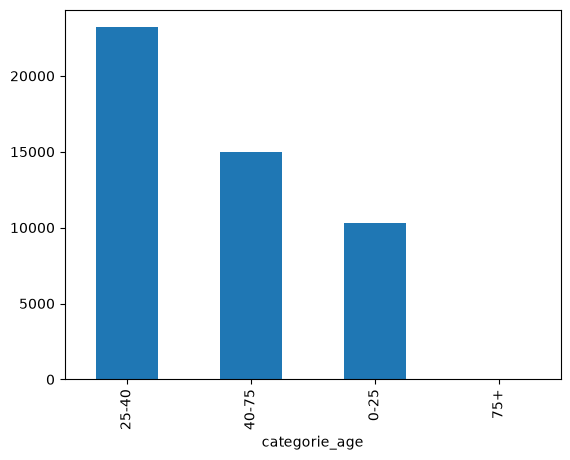

In [66]:
age.plot(kind='bar')